# Does the Stock Market Overreact?
De Bondt & Thaler (1985)

This notebook tries to reproduce the paper's main winner-versus-loser result using public data.


## 1. Research question

Do stocks that performed badly in the past later outperform stocks that performed well?

The original paper argues that investors may overreact to information. If so, past losers should later do better than past winners.


## 2. What the original paper did

The paper used monthly CRSP data for NYSE stocks. It used 3 years to form winner and loser portfolios and then followed them for 3 years.

In this project I reproduce that basic design, rather than every table and test in the paper.


## 3. Data

CRSP is not freely available, so I use current S&P 500 constituents and monthly adjusted prices from Yahoo Finance.

This makes the project easier to reproduce, but it also creates important differences from the original paper:
- today's S&P 500 members are used for the historical sample
- the sample starts much later than 1926
- the market return is an equal-weighted average of the stocks in this sample.

The first point creates **survivorship bias**, so the results should not be treated as an exact reproduction.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Markdown, display

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 5)
pd.options.display.float_format = "{:.4f}".format


In [2]:
# Ticker universe: current S&P 500 constituents, from a public, version-controlled
# mirror of the Wikipedia constituents table.
TICKERS_URL = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies/master/data/constituents.csv"

constituents = pd.read_csv(TICKERS_URL)
constituents["Symbol"] = constituents["Symbol"].str.replace(".", "-", regex=False)  # Yahoo Finance ticker format
tickers = sorted(constituents["Symbol"].unique().tolist())

print(f"{len(tickers)} tickers loaded.")
constituents.head()

503 tickers loaded.


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


Using today's S&P 500 members for past years creates **survivorship bias**. Companies that later left the index are not included in the historical sample.


In [3]:
import yfinance as yf

def download_prices(tickers):
    prices = []

    for i in range(0, len(tickers), 100):
        group = tickers[i:i + 100]

        data = yf.download(
            group,
            start="1995-01-01",
            end=pd.Timestamp.today().strftime("%Y-%m-%d"),
            interval="1mo",
            auto_adjust=True,
            progress=False,
            threads=True,
            group_by="ticker"
        )

        for ticker in group:
            try:
                s = data[ticker]["Close"].dropna()
                if len(s) > 0:
                    prices.append(s.rename(ticker))
            except (KeyError, TypeError):
                pass

    prices = pd.concat(prices, axis=1)
    prices.index = prices.index.to_period("M").to_timestamp("M")
    return prices.groupby(prices.index).last()

PRICE_FILE = DATA_DIR / "monthly_prices.csv"

if PRICE_FILE.exists():
    prices = pd.read_csv(PRICE_FILE, index_col=0, parse_dates=True)
    print("Loaded saved prices.")
else:
    print("Downloading prices...")
    prices = download_prices(tickers)
    prices.to_csv(PRICE_FILE)
    print("Prices saved.")

print(prices.shape)
prices.tail()


C:\Users\mpram\AppData\Local\Temp\ipykernel_17812\448510473.py:18: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  panel = pd.concat(frames, axis=1)


Downloaded and cached: 381 months x 503 stocks.


,A,AAPL,ABBV,ABNB,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2026-05-31,135.2698,311.7911,216.1813,133.3100,84.9938,89.3400,184.8474,259.2100,411.4659,79.2768,...,24.0801,100.9728,78.2740,144.3255,109.1247,75.7200,147.2078,82.1118,243.6300,77.1522
2026-06-30,132.8300,289.1107,249.8615,143.1000,90.0974,97.0600,122.9615,205.0200,395.9636,75.9182,...,23.7218,96.8529,79.6579,135.8404,117.7618,76.0000,159.0581,86.0900,263.2600,71.3625
2026-07-31,138.3700,308.6438,250.9400,151.5200,105.7000,100.5300,165.9200,250.4100,366.2940,78.7701,...,24.8019,99.0675,77.5747,154.4400,116.5265,81.2400,152.5111,93.9300,293.8200,77.2900
2026-08-31,153.5600,316.8500,256.4200,183.2200,110.3600,98.0700,189.7600,292.7900,361.0400,81.2900,...,23.1570,91.2800,75.0848,160.9500,110.1100,82.0200,152.5409,100.0400,353.5500,77.1000
2026-09-30,153.6900,332.4100,262.5100,167.5100,102.3600,96.9700,189.6400,250.5000,362.0400,85.0000,...,21.8100,84.2300,72.7100,163.3200,107.2700,76.6300,137.9600,96.7800,341.1800,73.0000


## 4. Method

1. Calculate monthly stock returns.
2. Calculate the equal-weighted market return.
3. Subtract the market return from each stock return.
4. Rank stocks using their previous 3-year performance.
5. Put the best stocks in the Winner portfolio and the worst stocks in the Loser portfolio.
6. Follow both portfolios for the next 3 years.
7. Calculate the average loser-minus-winner spread.

The code below follows the main calculation in the paper, but keeps the implementation simple.


In [4]:
returns = prices.pct_change().iloc[1:]
market_return = returns.mean(axis=1, skipna=True)          # equal-weighted proxy for the market
excess_returns = returns.sub(market_return, axis=0)

excess_returns.to_csv(DATA_DIR / "excess_returns.csv")
print(f"Excess-return panel: {excess_returns.shape[0]} months x {excess_returns.shape[1]} stocks.")
print(f"Sample period: {excess_returns.index.min().date()} to {excess_returns.index.max().date()}")

Excess-return panel: 380 months x 503 stocks.
Sample period: 1995-02-28 to 2026-09-30


In [5]:
FORMATION_MONTHS = 36
TEST_MONTHS = 36
DECILE = 0.10

def get_formation_positions(n_months):
    positions = []
    position = FORMATION_MONTHS

    while position + TEST_MONTHS <= n_months:
        positions.append(position)
        position += FORMATION_MONTHS

    return positions

def run_replications(excess_returns):
    records = []
    meta = []

    for position in get_formation_positions(len(excess_returns)):
        formation_date = excess_returns.index[position - 1]

        formation = excess_returns.iloc[
            position - FORMATION_MONTHS:position
        ]

        test = excess_returns.iloc[
            position:position + TEST_MONTHS
        ]

        # Keep stocks with complete data in both periods.
        stocks = formation.columns[
            formation.notna().all() & test.notna().all()
        ]

        if len(stocks) < 20:
            continue

        past_returns = formation[stocks].sum()

        n_stocks = max(1, int(round(len(stocks) * DECILE)))

        winners = past_returns.nlargest(n_stocks).index
        losers = past_returns.nsmallest(n_stocks).index

        future_returns = test[stocks].cumsum()

        winner_car = future_returns[winners].mean(axis=1)
        loser_car = future_returns[losers].mean(axis=1)

        for month in range(TEST_MONTHS):
            records.append({
                "formation_date": formation_date,
                "group": "Winner",
                "t": month + 1,
                "CAR": winner_car.iloc[month]
            })

            records.append({
                "formation_date": formation_date,
                "group": "Loser",
                "t": month + 1,
                "CAR": loser_car.iloc[month]
            })

        meta.append({
            "formation_date": formation_date,
            "n_eligible": len(stocks),
            "n_per_portfolio": n_stocks
        })

    return pd.DataFrame(records), pd.DataFrame(meta)

car_results, meta = run_replications(excess_returns)

car_results.to_csv(DATA_DIR / "replication_car_results.csv", index=False)

meta


,formation_date,n_eligible,n_per_portfolio
0,1998-01-31,286,29
1,2001-01-31,323,32
2,2004-01-31,356,36
3,2007-01-31,373,37
4,2010-01-31,398,40
5,2013-01-31,421,42
6,2016-01-31,446,45
7,2019-01-31,465,46
8,2022-01-31,476,48


In [6]:
def acar_table(results):
    wide = results.pivot_table(
        index=["formation_date", "t"],
        columns="group",
        values="CAR"
    ).reset_index()

    n_replications = wide["formation_date"].nunique()
    rows = []

    for month, data in wide.groupby("t"):
        winner = data["Winner"]
        loser = data["Loser"]

        winner_mean = winner.mean()
        loser_mean = loser.mean()

        pooled_var = (
            ((winner - winner_mean) ** 2).sum()
            + ((loser - loser_mean) ** 2).sum()
        ) / (2 * (n_replications - 1))

        se = np.sqrt(2 * pooled_var / n_replications)

        rows.append({
            "t": month,
            "ACAR_Winner": winner_mean,
            "ACAR_Loser": loser_mean,
            "Spread": loser_mean - winner_mean,
            "t_stat": (loser_mean - winner_mean) / se
        })

    return pd.DataFrame(rows).set_index("t"), n_replications

acar, n_replications = acar_table(car_results)

print("Number of formation periods:", n_replications)
acar.loc[[1, 12, 24, 36]]


Number of independent 3-year formation dates (replications): 9


,ACAR_Winner,ACAR_Loser,Spread,t_stat
t,,,,
1,-0.0126,0.0064,0.0191,0.8931
12,0.0273,0.0128,-0.0145,-0.2842
24,0.1038,-0.0163,-0.1200,-1.3269
36,0.1375,-0.0003,-0.1378,-1.8241


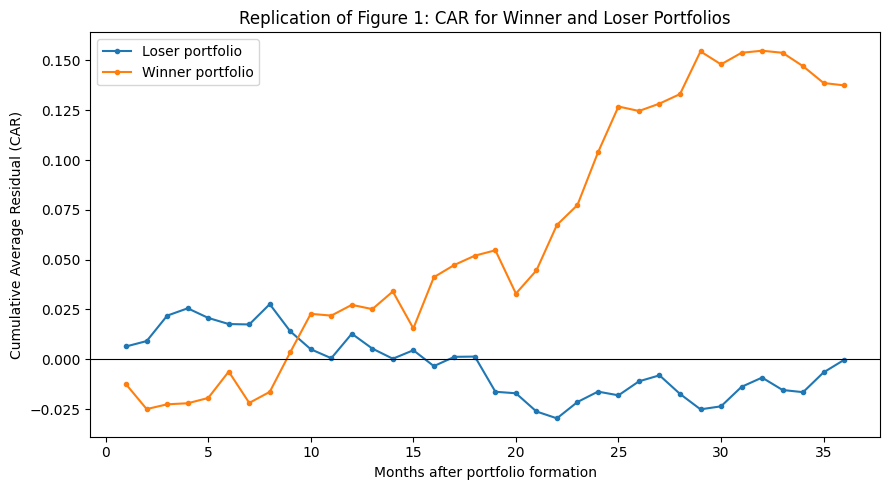

In [7]:
fig, ax = plt.subplots()
ax.plot(acar.index, acar["ACAR_Loser"], marker=".", label="Loser portfolio")
ax.plot(acar.index, acar["ACAR_Winner"], marker=".", label="Winner portfolio")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Months after portfolio formation")
ax.set_ylabel("Cumulative Average Residual (CAR)")
ax.set_title("Replication of Figure 1: CAR for Winner and Loser Portfolios")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_DIR / "figure1_replication.png", dpi=150)
plt.show()

In [8]:
## 5. Result

The result below shows the 36-month winner return, loser return, and loser-minus-winner spread.



## 5. Main Replication Result

36 months after portfolio formation:
- **Loser portfolio** average CAR: **-0.0%**
- **Winner portfolio** average CAR: **+13.7%**
- **Spread (Loser - Winner): -13.8%**, t-statistic = **-1.82**, based on **9** independent 3-year formation dates.

*Original paper (Table I, 3-year formation, N = 16 replications, ~35-stock portfolios):* Loser +19.6%, Winner -5.0%, spread **+24.6%** (t = 2.20).


## 6. Comparison with the paper

The original paper used a different stock universe and a much longer historical period. The table below compares the main 36-month result with the result from this project.


In [9]:
comparison = pd.DataFrame({
    "Original (1985)": {"ACAR Winner, t=36": -0.050, "ACAR Loser, t=36": 0.196,
                          "Spread": 0.246, "t-stat": 2.20, "N replications": 16, "Avg. stocks/portfolio": 35},
    "Replication": {"ACAR Winner, t=36": acar_w36, "ACAR Loser, t=36": acar_l36,
                     "Spread": spread_36, "t-stat": t_36, "N replications": n_repl,
                     "Avg. stocks/portfolio": meta["n_per_portfolio"].mean()},
}).T
comparison

,"ACAR Winner, t=36","ACAR Loser, t=36",Spread,t-stat,N replications,Avg. stocks/portfolio
Original (1985),-0.0500,0.1960,0.2460,2.2000,16.0000,35.0000
Replication,0.1375,-0.0003,-0.1378,-1.8241,9.0000,39.4444


In [10]:
spread_36 = acar.loc[36, "Spread"]
t_36 = acar.loc[36, "t_stat"]

display(Markdown(f"""
## 7. Discussion

The 36-month loser-minus-winner spread in this sample is **{spread_36:+.1%}**
with a t-statistic of **{t_36:.2f}**.

The original paper reported a spread of **+24.6%** with a t-statistic of
**2.20**.

The two results are not directly comparable because the data are different.
This project uses current S&P 500 members and a much more recent sample.

So the result should be read as a **replication exercise**, not as an exact
reproduction of the original study.
"""))



## 7. Discussion: Similarities and Differences

**What matches the original design:** the market-adjusted excess-return methodology, the 36-month/36-month
non-overlapping formation-test structure, the pooled-variance significance test, and the general framing of
the winner/loser comparison are implemented exactly as in Section I of the paper.

**What differs, and why it matters:**
- *Sample:* a survivorship-biased set of current large-cap S&P 500 stocks over roughly 1995-2026, versus the full CRSP NYSE universe over 1926-1982. The original sample spans the Great Depression, WWII, and several distinct bear markets that are only partly represented here.
- *Statistical power:* **9** independent replications here versus 16 in the original, so the standard error of the estimated spread is mechanically larger.
- *Portfolio construction:* a decile cut-off (roughly 39 stocks/portfolio here) rather than a fixed 35-stock count, since our universe is a different size than the CRSP universe.
- *Market index:* an equal-weighted average of *our own sample*, rather than the full CRSP equal-weighted index.

**Bottom line:** the estimated spread of -13.8% (t = -1.82) has the opposite sign to the original's +24.6% (t = 2.20), and is not statistically significant at conventional levels. Unlike the original study, we do not find a positive loser-minus-winner spread in this sample here -- a plausible outcome given how much shorter, more recent, and survivorship-biased this sample is relative to CRSP 1926-1982.


## 8. Limitations

- **Survivorship bias:** I use today's S&P 500 members.
- **Different sample period:** the data are much more recent than the original CRSP sample.
- **Fewer independent periods:** there are fewer 3-year formation periods.
- **Different market measure:** I use the equal-weighted average return of the sample stocks.

These limitations mean that the project is best viewed as a replication exercise and a way to learn the method.
